# Validate model

Mostly redundant honestly, we do the important stuff in train.ipynb

In [22]:
run = "k"

In [23]:
import sys
sys.path.append("../src/ml")

In [24]:
from load import LoadML
loader = LoadML(run=run)
results = loader.load_training_results("final")
print(results.keys())

from validate import Validate
val = Validate(results, run=run)

[LoadML] ✅ Initialised
[LoadML] ✅ Loaded training results for 'final' from /exp/mu2e/app/users/sgrant/MLTrain/CrvCosmic/output/ml/k/results/final
dict_keys(['tag', 'model', 'feature_names', 'y_train', 'y_val', 'y_test', 'y_pred', 'y_proba', 'y_pred_val', 'y_proba_val', 'y_proba_train', 'X_val', 'X_test', 'scaler', 'metadata_val', 'metadata_test', 'cv_threshold', 'cv_threshold_std'])
[Validate] ✅ Initialised analyser for model: final


In [25]:
help(val)

Help on Validate in module validate object:

class Validate(builtins.object)
 |  Validate(results, run='j', img_out_path=None, verbosity=1)
 |
 |  Validate and analyse trained model. Works with results dict from Train.train().
 |
 |  Methods defined here:
 |
 |  __init__(self, results, run='j', img_out_path=None, verbosity=1)
 |      Initialise with Train.train() results dict.
 |
 |  cv_money_table(self, fold_raws, save_csv=True)
 |      Display CV-averaged money table from list of fold raw dicts.
 |
 |      Args:
 |          fold_raws: list of raw dicts from money_table()["raw"], one per fold.
 |          save_csv: whether to save the table to CSV.
 |
 |  find_threshold(self, min_eff=0.999, n_thresholds=10000, plot=True, out_path=None, show=True)
 |      Find highest threshold meeting min_eff event-level veto efficiency.
 |
 |  get_events_by_threshold(self, threshold, above=False)
 |      Select test events by event-level max score. Returns DataFrame with all coincidences.
 |
 |  mone


Feature importance (gain):
  crv_z          : 489.9995
  nLayers        : 366.1406
  dT             : 288.1821
  PEs            : 185.9877
  nHits          : 153.1056
  angle          : 20.5342
  crv_x          : 15.5406
  crv_y          : 8.3965
[Validate] ✅ Saved to /exp/mu2e/app/users/sgrant/MLTrain/CrvCosmic/output/images/ml/k/final/bar_feature_importance_gain.png


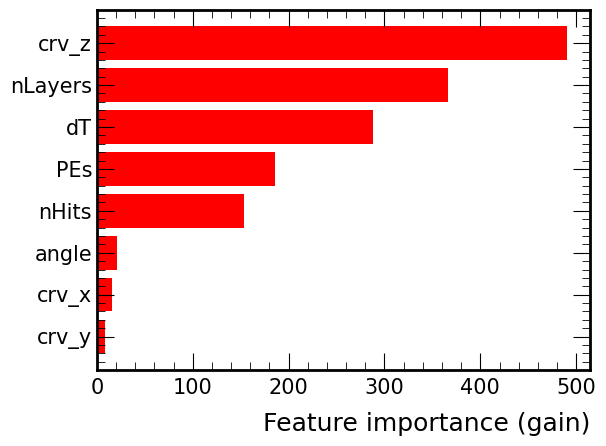

{'crv_x': 15.540645599365234,
 'crv_y': 8.396490097045898,
 'crv_z': 489.99945068359375,
 'PEs': 185.9877471923828,
 'dT': 288.1820983886719,
 'nHits': 153.10556030273438,
 'nLayers': 366.1405944824219,
 'angle': 20.534231185913086}

In [26]:
val.plot_feature_importance()

[Validate] ✅ Saved to /exp/mu2e/app/users/sgrant/MLTrain/CrvCosmic/output/images/ml/k/final/roc_curve.png


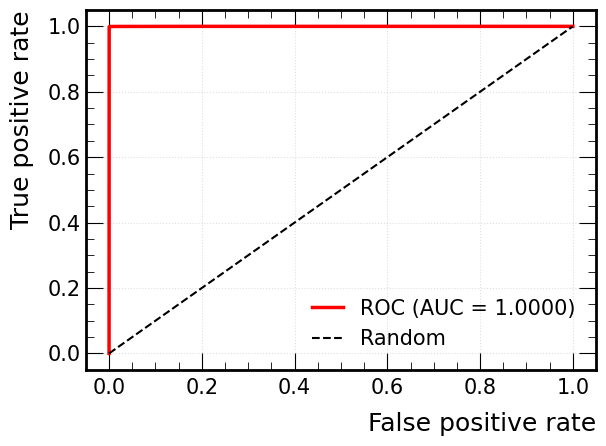

In [27]:
val.plot_roc(show=True)

In [31]:
# should be passed from training results
threshold = results["cv_threshold"]

In [32]:
threshold

0.16577657765776582

[Validate] ✅ Saved to /exp/mu2e/app/users/sgrant/MLTrain/CrvCosmic/output/images/ml/k/final/h1_score_distribution.png


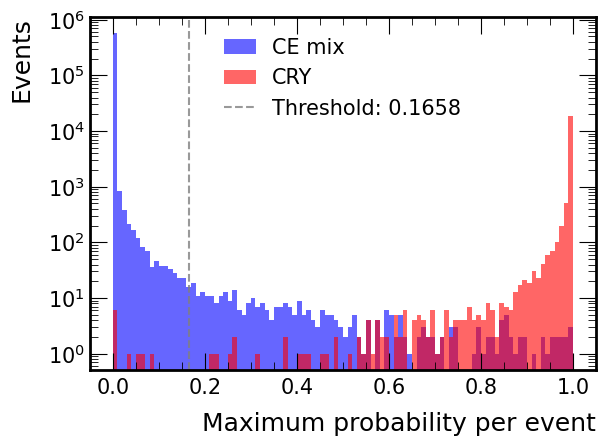

In [33]:
val.plot_score_distribution(threshold=threshold)

[Validate] ⭐️ Events below threshold 0.1658:
  CRY:    10
  CE mix: 578004
[Validate] ✅ Saved to /exp/mu2e/app/users/sgrant/MLTrain/CrvCosmic/output/images/ml/k/final/h1_low_score_physics.png


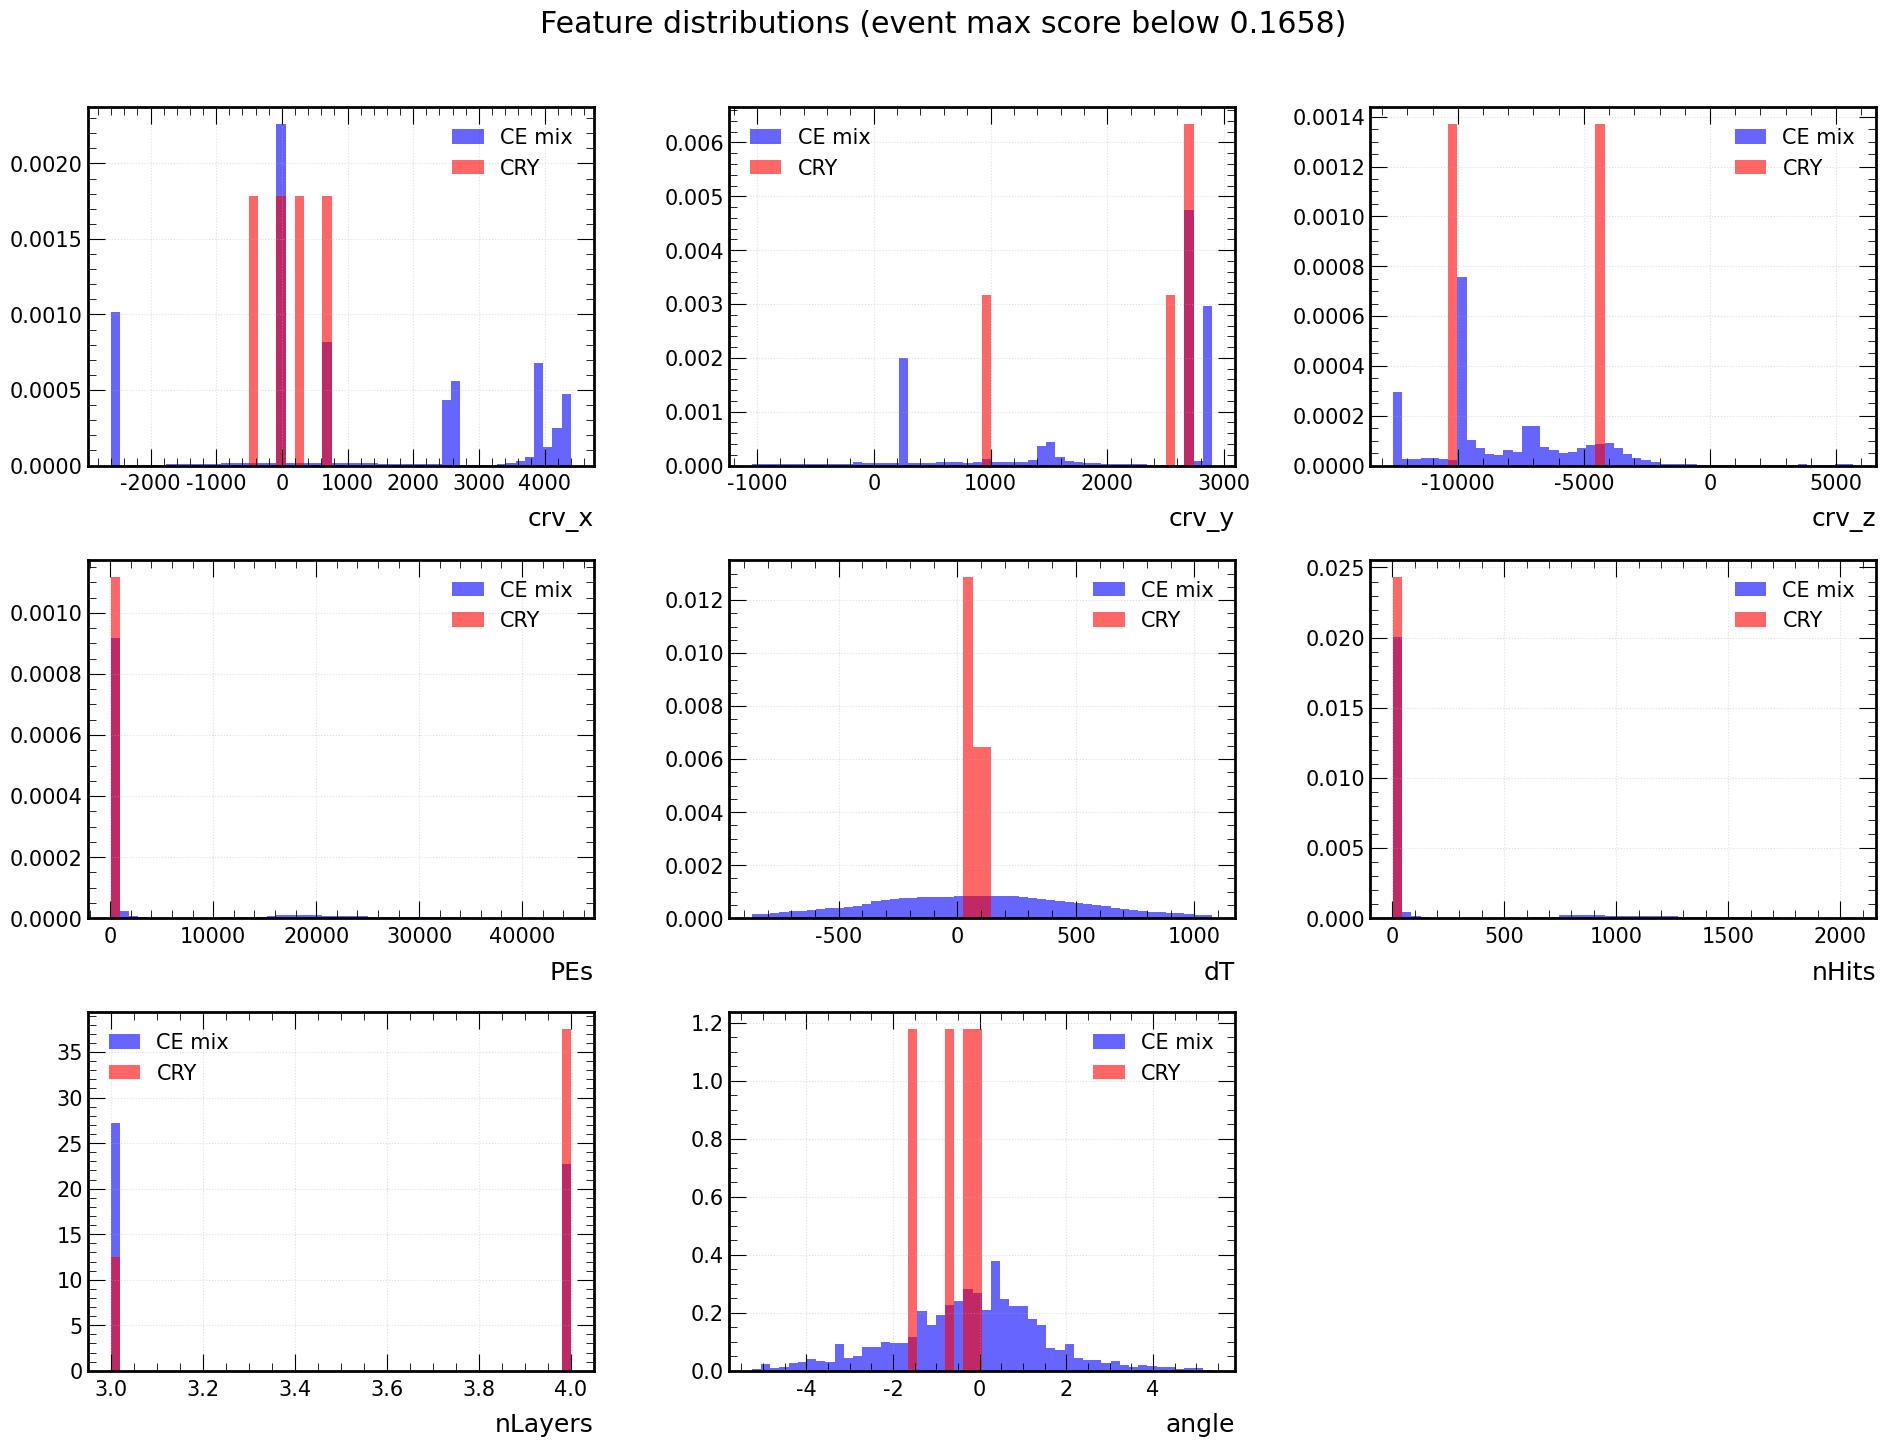

In [34]:
val.plot_physics_by_score(
    threshold=threshold,
    above=False
)

In [41]:
results.keys()

dict_keys(['tag', 'model', 'feature_names', 'y_train', 'y_val', 'y_test', 'y_pred', 'y_proba', 'y_pred_val', 'y_proba_val', 'y_proba_train', 'X_val', 'X_test', 'scaler', 'metadata_val', 'metadata_test', 'cv_threshold', 'cv_threshold_std'])

In [40]:
# df_money_cv = val.cv_money_table(results)
# display(df_money_cv)